IMPORTS AND SETUP

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

RANDOM_STATE = 42
TRAIN_RATIO  = 0.8

LOAD AND INSPECTING DATA

In [2]:
df = pd.read_csv('train.csv')
df['date'] = pd.to_datetime(df['date'])

print('Shape:', df.shape)
print('\nDtypes:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())
df.head()

Shape: (913000, 4)

Dtypes:
 date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

Missing values:
 date     0
store    0
item     0
sales    0
dtype: int64

Duplicates: 0


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


EDA: TIME SERIES PLOT

In [3]:
daily_sales = df.groupby('date')['sales'].sum().sort_index()

print('Total days        :', len(daily_sales))
print('Date range        :', daily_sales.index.min(), '→', daily_sales.index.max())
print('Unique sale values:', daily_sales.nunique())
print('\nBasic stats:')
print(daily_sales.describe().round(2))

Total days        : 1826
Date range        : 2013-01-01 00:00:00 → 2017-12-31 00:00:00
Unique sale values: 1747

Basic stats:
count     1826.00
mean     26125.14
std       6418.27
min      11709.00
25%      21195.00
50%      25839.50
75%      30779.50
max      44936.00
Name: sales, dtype: float64


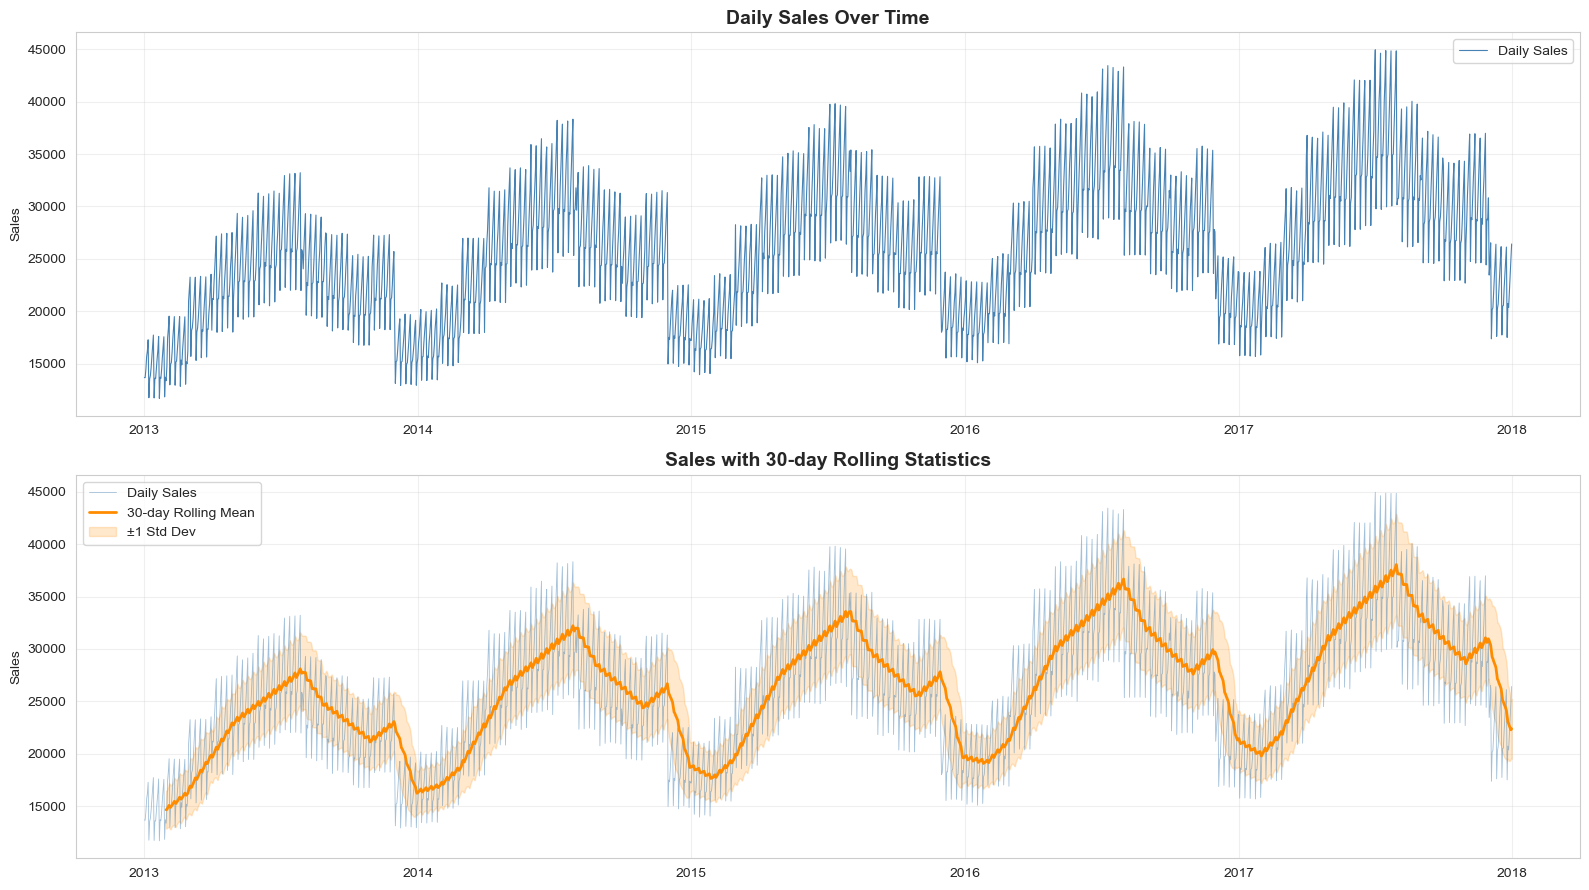

In [4]:
import os
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

axes[0].plot(daily_sales.index, daily_sales.values, color='steelblue', linewidth=0.8, label='Daily Sales')
axes[0].set_title('Daily Sales Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales')
axes[0].legend()

rolling_mean = daily_sales.rolling(window=30).mean()
rolling_std  = daily_sales.rolling(window=30).std()

axes[1].plot(daily_sales.index, daily_sales.values, color='steelblue', linewidth=0.6, alpha=0.5, label='Daily Sales')
axes[1].plot(daily_sales.index, rolling_mean, color='darkorange', linewidth=2, label='30-day Rolling Mean')
axes[1].fill_between(daily_sales.index,
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     alpha=0.2, color='darkorange', label='±1 Std Dev')
axes[1].set_title('Sales with 30-day Rolling Statistics', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sales')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/01_eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

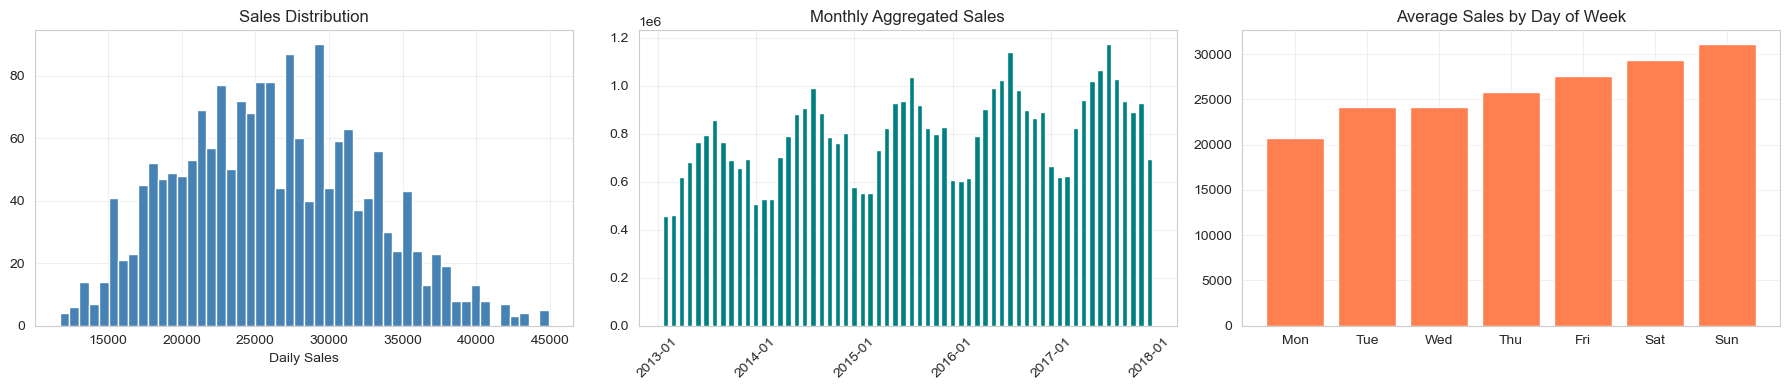

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(daily_sales.values, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Daily Sales')

monthly = daily_sales.resample('M').sum()
axes[1].bar(monthly.index, monthly.values, color='teal', width=20)
axes[1].set_title('Monthly Aggregated Sales')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

dow_sales = daily_sales.groupby(daily_sales.index.dayofweek).mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[2].bar(dow_labels, dow_sales.values, color='coral')
axes[2].set_title('Average Sales by Day of Week')

plt.tight_layout()
plt.savefig('plots/02_eda_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

STATIONARY AND DECOMPOSITION

In [6]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales, autolag='AIC')

print('=' * 45)
print('Augmented Dickey-Fuller Test')
print('=' * 45)
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.6f}')
print(f'Lags Used     : {result[2]}')
for key, val in result[4].items():
    print(f'  Critical ({key}): {val:.4f}')

if result[1] < 0.05:
    print('\n Series is STATIONARY (p < 0.05)')
else:
    print('\n  Series is NON-STATIONARY (p ≥ 0.05)')

Augmented Dickey-Fuller Test
ADF Statistic : -3.0602
p-value       : 0.029639
Lags Used     : 21
  Critical (1%): -3.4340
  Critical (5%): -2.8631
  Critical (10%): -2.5676

 Series is STATIONARY (p < 0.05)


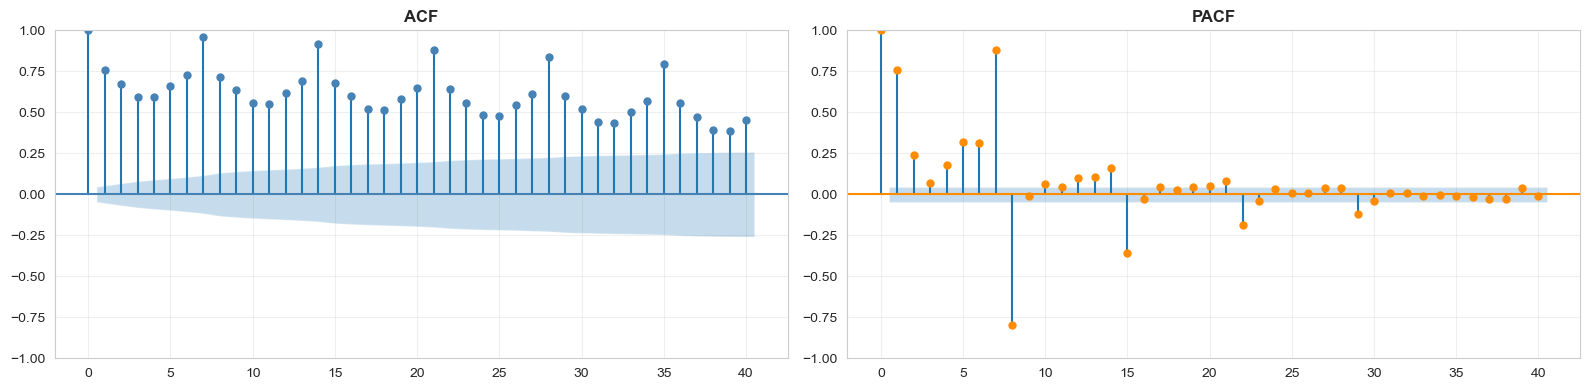

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(daily_sales, lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF', fontweight='bold')
plot_pacf(daily_sales, lags=40, ax=axes[1], color='darkorange')
axes[1].set_title('PACF', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

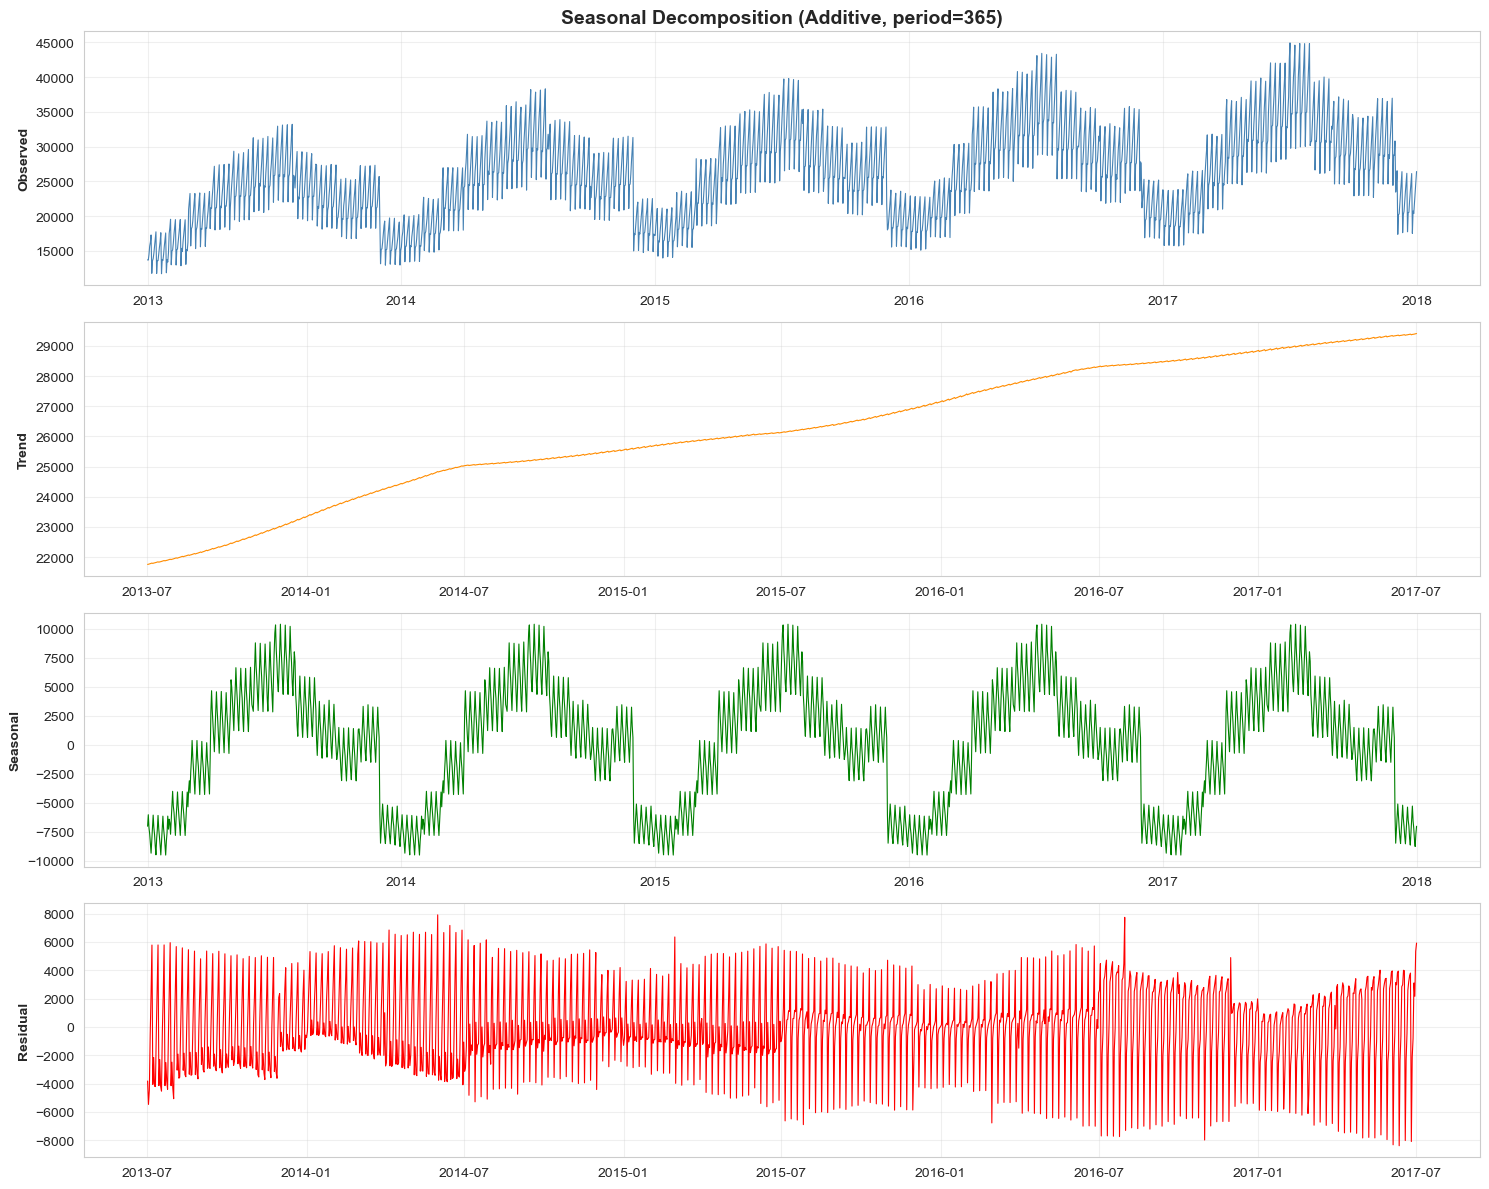

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(daily_sales, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
components = [
    (decomp.observed, 'Observed', 'steelblue'),
    (decomp.trend,    'Trend',    'darkorange'),
    (decomp.seasonal, 'Seasonal', 'green'),
    (decomp.resid,    'Residual', 'red'),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=0.8)
    ax.set_ylabel(label, fontweight='bold')
axes[0].set_title('Seasonal Decomposition (Additive, period=365)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

TRAIN AND TEST SPLIT

Train: 1460 days  (2013-01-01 → 2016-12-30)
Test : 366 days  (2016-12-31 → 2017-12-31)


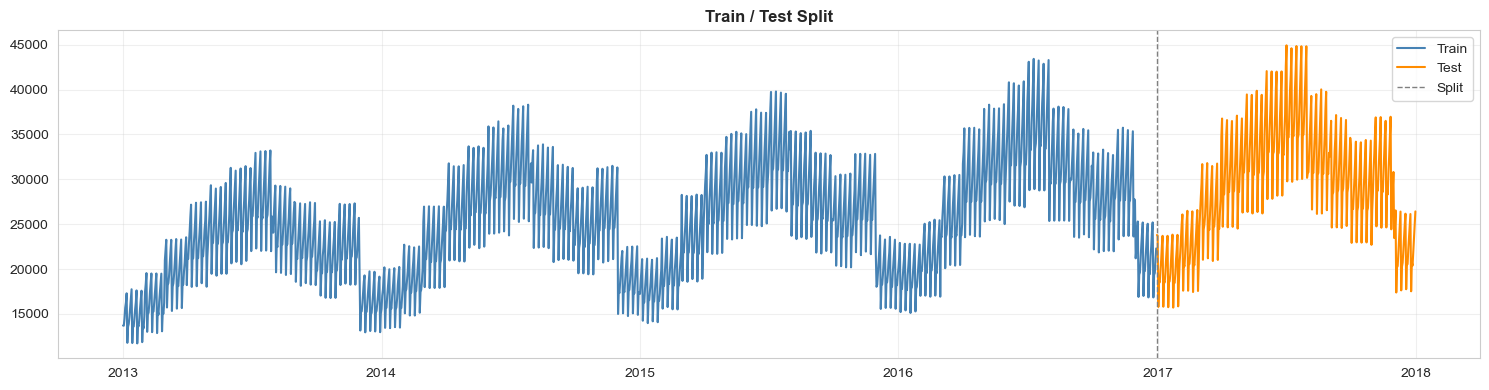

In [9]:
split = int(len(daily_sales) * TRAIN_RATIO)
train = daily_sales[:split]
test  = daily_sales[split:]

print(f'Train: {len(train)} days  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test : {len(test)} days  ({test.index.min().date()} → {test.index.max().date()})')

plt.figure(figsize=(15, 4))
plt.plot(train.index, train.values, label='Train', color='steelblue')
plt.plot(test.index,  test.values,  label='Test',  color='darkorange')
plt.axvline(test.index[0], color='gray', linestyle='--', linewidth=1, label='Split')
plt.title('Train / Test Split', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/05_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

ARIMA MODEL

In [10]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1, 0, 1))
arima_fit   = arima_model.fit()
print(arima_fit.summary())

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1460
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -14041.143
Date:                Mon, 22 Jun 2026   AIC                          28090.286
Time:                        00:03:52   BIC                          28111.431
Sample:                    01-01-2013   HQIC                         28098.174
                         - 12-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.53e+04   2605.921      9.711      0.000    2.02e+04    3.04e+04
ar.L1          0.9961      0.003    396.871      0.000       0.991       1.001
ma.L1         -0.8628      0.013    -64.718      0.0

MAE  : 7171.93
RMSE : 8807.94
MAPE : 22.29%


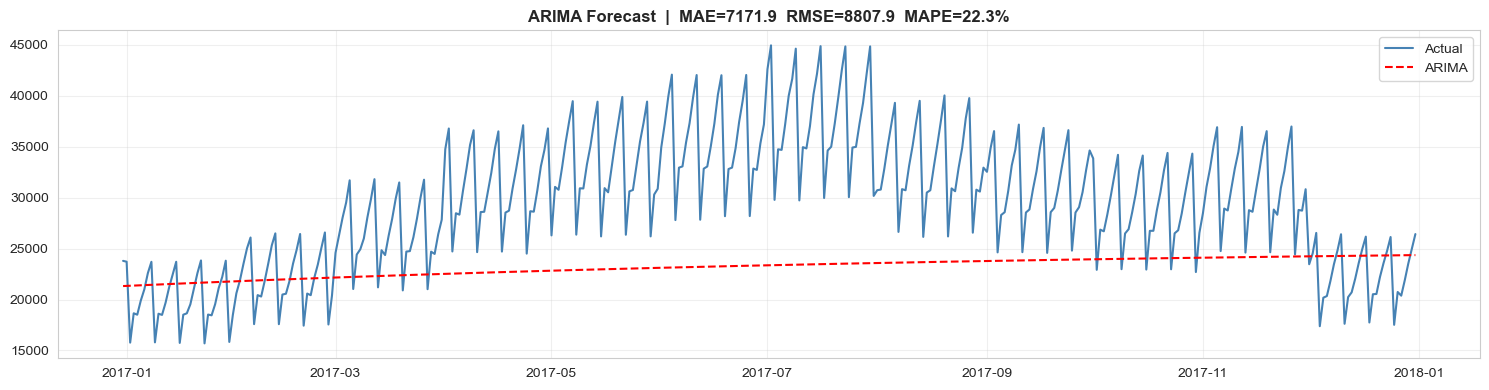

In [11]:
arima_pred = arima_fit.forecast(steps=len(test))
arima_pred.index = test.index

arima_mae  = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(((test - arima_pred) ** 2).mean())
arima_mape = mean_absolute_percentage_error(test, arima_pred) * 100

print(f'MAE  : {arima_mae:.2f}')
print(f'RMSE : {arima_rmse:.2f}')
print(f'MAPE : {arima_mape:.2f}%')

plt.figure(figsize=(15, 4))
plt.plot(test.index, test.values,       label='Actual', color='steelblue')
plt.plot(test.index, arima_pred.values, label='ARIMA',  color='red', linestyle='--')
plt.title(f'ARIMA Forecast  |  MAE={arima_mae:.1f}  RMSE={arima_rmse:.1f}  MAPE={arima_mape:.1f}%', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/06_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

PROPHET MODEL

00:04:34 - cmdstanpy - INFO - Chain [1] start processing
00:04:35 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 1486.77
RMSE : 1776.32
MAPE : 5.62%


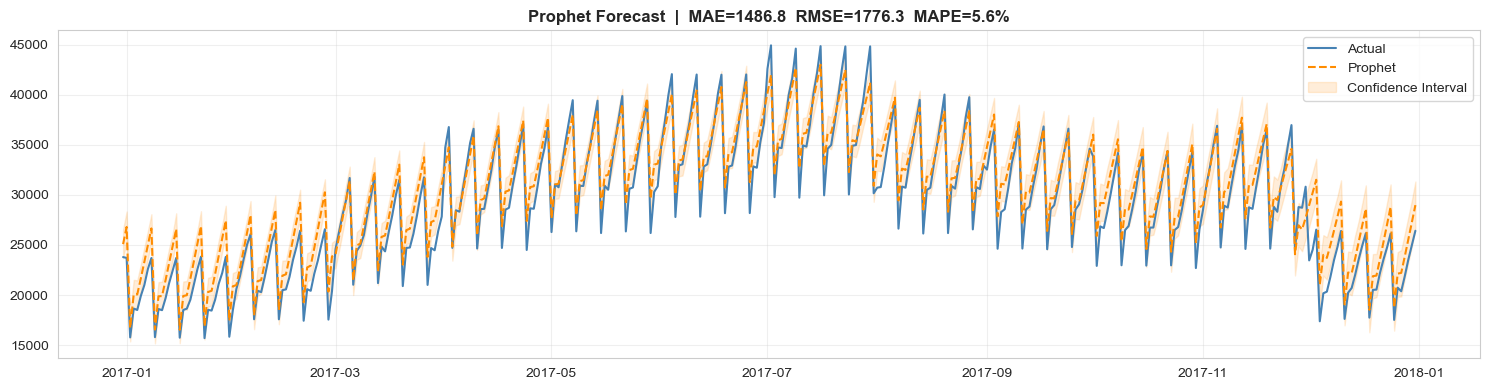

In [12]:
from prophet import Prophet

train_prophet = train.reset_index()
train_prophet.columns = ['ds', 'y']

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)
prophet_model.fit(train_prophet)

future   = pd.DataFrame({'ds': test.index})
forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'].values

prophet_mae  = mean_absolute_error(test.values, prophet_pred)
prophet_rmse = np.sqrt(((test.values - prophet_pred) ** 2).mean())
prophet_mape = mean_absolute_percentage_error(test.values, prophet_pred) * 100

print(f'MAE  : {prophet_mae:.2f}')
print(f'RMSE : {prophet_rmse:.2f}')
print(f'MAPE : {prophet_mape:.2f}%')

plt.figure(figsize=(15, 4))
plt.plot(test.index, test.values,  label='Actual',  color='steelblue')
plt.plot(test.index, prophet_pred, label='Prophet', color='darkorange', linestyle='--')
plt.fill_between(test.index,
                 forecast['yhat_lower'].values,
                 forecast['yhat_upper'].values,
                 alpha=0.15, color='darkorange', label='Confidence Interval')
plt.title(f'Prophet Forecast  |  MAE={prophet_mae:.1f}  RMSE={prophet_rmse:.1f}  MAPE={prophet_mape:.1f}%', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/07_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

PROPHET COMPONENTS PLOTS

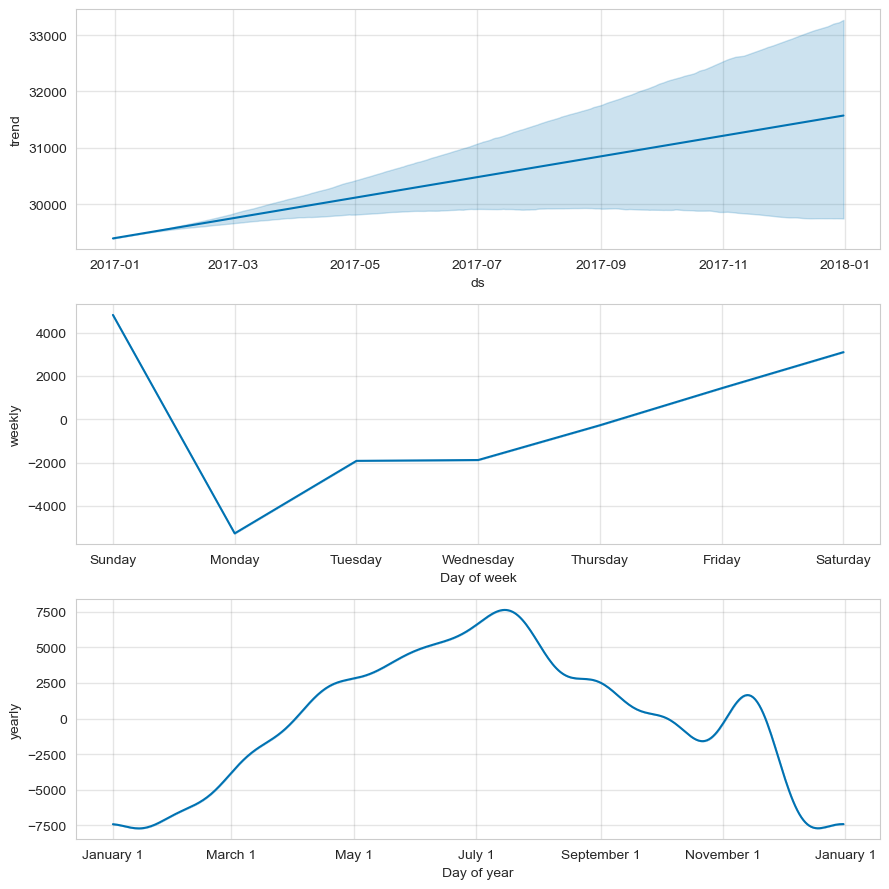

In [24]:
fig = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.savefig('plots/08_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

XGBOOST MODEL

In [14]:
def create_features(series):
    ts = series.reset_index()
    ts.columns = ['date', 'sales']

    ts['year']       = ts['date'].dt.year
    ts['month']      = ts['date'].dt.month
    ts['day']        = ts['date'].dt.day
    ts['dayofweek']  = ts['date'].dt.dayofweek
    ts['quarter']    = ts['date'].dt.quarter
    ts['weekofyear'] = ts['date'].dt.isocalendar().week.astype(int)
    ts['is_weekend'] = (ts['dayofweek'] >= 5).astype(int)

    for lag in [1, 7, 14, 30]:
        ts[f'lag_{lag}'] = ts['sales'].shift(lag)

    for window in [7, 14, 30]:
        ts[f'rolling_mean_{window}'] = ts['sales'].rolling(window).mean()
        ts[f'rolling_std_{window}']  = ts['sales'].rolling(window).std()

    return ts.dropna()

ts_df = create_features(daily_sales)
print('Feature matrix shape:', ts_df.shape)
ts_df.head()

Feature matrix shape: (1796, 19)


,date,sales,year,month,day,dayofweek,quarter,weekofyear,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30
30,2013-01-31,14724,2013,1,31,3,1,5,0,13391.0,14472.0,14587.0,13696.0,14781.000000,1974.427005,14741.857143,1885.091014,14706.933333,1791.430654
31,2013-02-01,17473,2013,2,1,4,1,5,0,14724.0,15640.0,15495.0,13678.0,15042.857143,2214.315954,14883.142857,2015.494589,14833.433333,1849.322741
32,2013-02-02,18323,2013,2,2,5,1,5,1,17473.0,16561.0,16294.0,14488.0,15294.571429,2497.673241,15028.071429,2190.133100,14961.266667,1954.194021
33,2013-02-03,19544,2013,2,3,6,1,5,1,18323.0,17579.0,17612.0,15677.0,15575.285714,2878.589221,15166.071429,2414.813051,15090.166667,2123.254400
34,2013-02-04,12998,2013,2,4,0,1,6,0,19544.0,11848.0,11709.0,16237.0,15739.571429,2654.507792,15258.142857,2294.436376,14982.200000,2145.165365


In [15]:
FEATURE_COLS = [
    'year', 'month', 'day', 'dayofweek', 'quarter', 'weekofyear', 'is_weekend',
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
    'rolling_std_7',  'rolling_std_14',  'rolling_std_30'
]

X = ts_df[FEATURE_COLS]
y = ts_df['sales']

split_xgb = int(len(ts_df) * TRAIN_RATIO)
X_train, X_test = X[:split_xgb], X[split_xgb:]
y_train, y_test = y[:split_xgb], y[split_xgb:]

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 1436 | Test: 360


In [17]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print(' XGBoost trained')

 XGBoost trained


MAE  : 547.53
RMSE : 831.62
MAPE : 1.85%


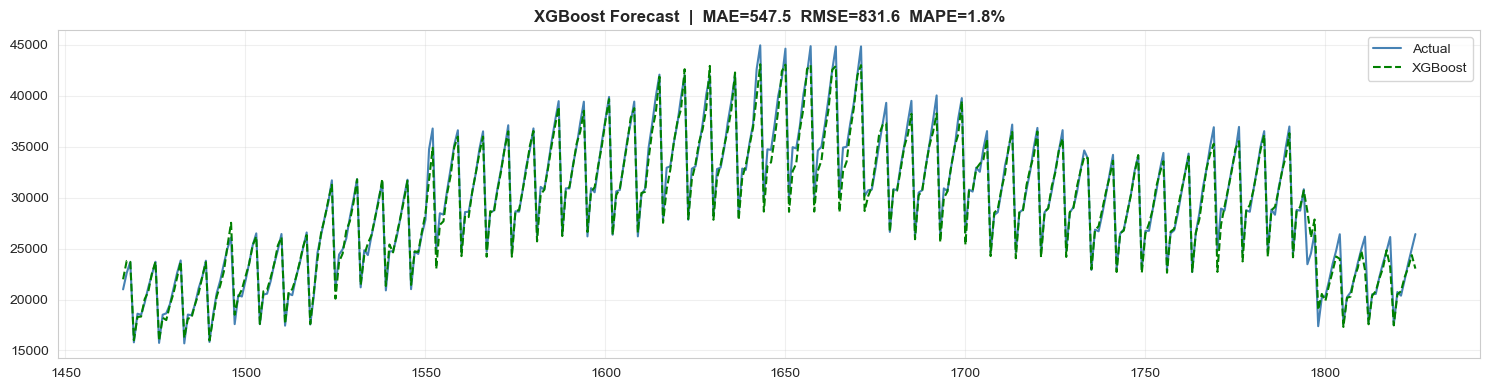

In [18]:
xgb_pred = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(((y_test.values - xgb_pred) ** 2).mean())
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100

print(f'MAE  : {xgb_mae:.2f}')
print(f'RMSE : {xgb_rmse:.2f}')
print(f'MAPE : {xgb_mape:.2f}%')

plt.figure(figsize=(15, 4))
plt.plot(y_test.index, y_test.values, label='Actual',  color='steelblue')
plt.plot(y_test.index, xgb_pred,      label='XGBoost', color='green', linestyle='--')
plt.title(f'XGBoost Forecast  |  MAE={xgb_mae:.1f}  RMSE={xgb_rmse:.1f}  MAPE={xgb_mape:.1f}%', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/09_xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
results = pd.DataFrame({
    'Model': ['ARIMA(1,0,1)', 'Prophet', 'XGBoost'],
    'MAE':   [arima_mae,      prophet_mae,   xgb_mae],
    'RMSE':  [arima_rmse,     prophet_rmse,  xgb_rmse],
    'MAPE':  [arima_mape,     prophet_mape,  xgb_mape]
}).set_index('Model').round(2)

print(results.to_string())
print(f'\n Best MAE : {results["MAE"].idxmin()}')
print(f' Best RMSE : {results["RMSE"].idxmin()}')
print(f' Best MAPE : {results["MAPE"].idxmin()}')

                  MAE     RMSE   MAPE
Model                                
ARIMA(1,0,1)  7171.93  8807.94  22.29
Prophet       1486.77  1776.32   5.62
XGBoost        547.53   831.62   1.85

 Best MAE : XGBoost
 Best RMSE : XGBoost
 Best MAPE : XGBoost


MODEL COMPARISON

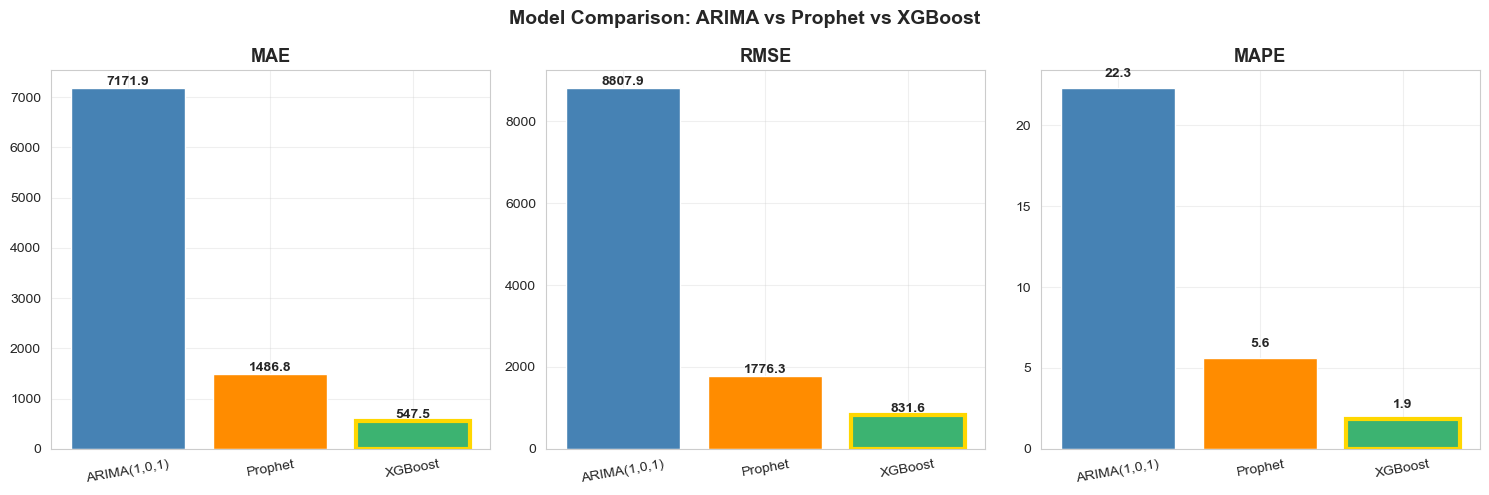

In [21]:
metrics = ['MAE', 'RMSE', 'MAPE']
colors  = ['steelblue', 'darkorange', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, metrics):
    bars = ax.bar(results.index, results[metric], color=colors, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    bars[results[metric].values.argmin()].set_edgecolor('gold')
    bars[results[metric].values.argmin()].set_linewidth(3)

plt.suptitle('Model Comparison: ARIMA vs Prophet vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

ALL FORECAST ON ONE CHART

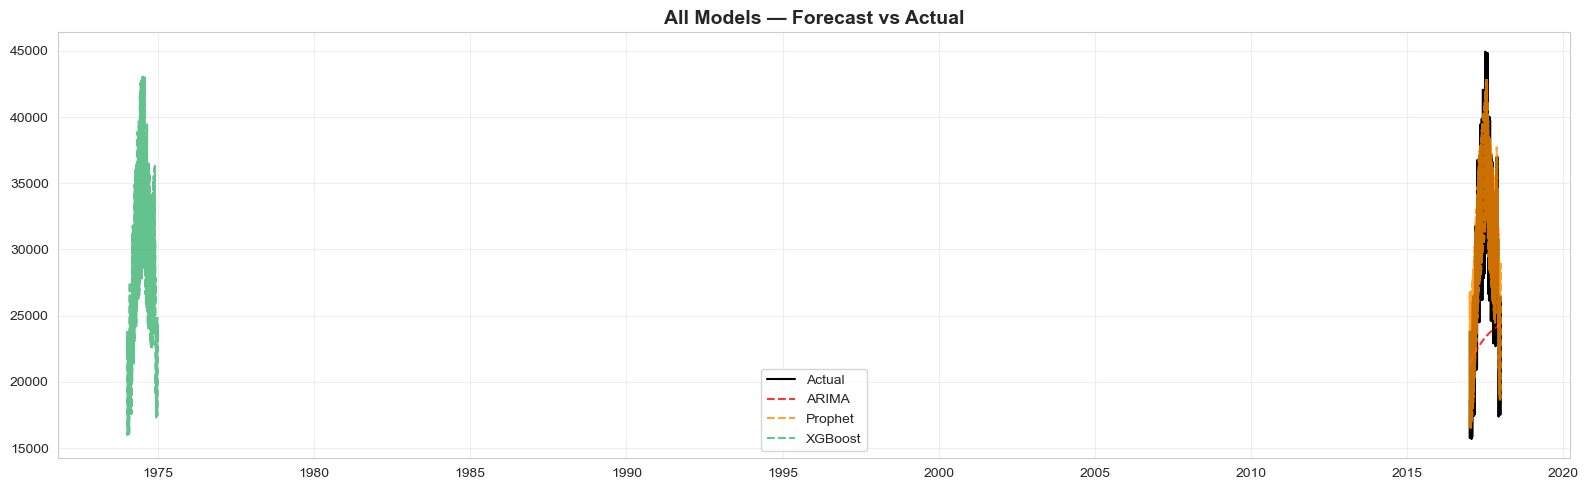

In [25]:
plt.figure(figsize=(16, 5))
plt.plot(test.index,   test.values,       label='Actual',  color='black',         linewidth=1.5)
plt.plot(test.index,   arima_pred.values, label='ARIMA',   color='red',           linestyle='--', alpha=0.8)
plt.plot(test.index,   prophet_pred,      label='Prophet', color='darkorange',    linestyle='--', alpha=0.8)
plt.plot(y_test.index, xgb_pred,          label='XGBoost', color='mediumseagreen',linestyle='--', alpha=0.8)
plt.title('All Models — Forecast vs Actual', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('plots/12_all_forecasts_overlay.png', dpi=150, bbox_inches='tight')
plt.show()